<a href="https://colab.research.google.com/github/beenishtech/Loan-Approval-Prediction-ML/blob/main/Loan_Approval_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#Data Read and view

In [ ]:
df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')

print("Dataset Shape")
print(df.shape)

print("\nColumns & Data Types")
print(df.dtypes)

print("\nMissing Values Count")
print(df.isnull().sum())

Dataset Shape
(614, 13)

Columns & Data Types
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing Values Count
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


#DATA PREPROCESSING

In [ ]:
# Handle Missing Values
# Loop through all columns to check and handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0: # If the column has missing values
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0]) # If the column is text (object), fill missing values with Mode
        else:
            df[col] = df[col].fillna(df[col].median()) # If the column is numeric, fill missing values with Median

#  Remove Duplicates if exist
df.drop_duplicates(inplace=True)

# Encode Categorical Variables (Text convert in numbers)
le = LabelEncoder()
# select thoes columns Automatic which are text columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# if Loan_ID exist so then remove it from encoding cuz it just a name/id.
if 'Loan_ID' in categorical_cols:
    categorical_cols.remove('Loan_ID')

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Feature Engineering & Train-Test Split Data

In [ ]:
# Feature (X) and Target (y) Split
X = df.drop(columns=['Loan_ID', 'Loan_Status'], errors='ignore')
y = df['Loan_Status']

# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#EXPLORATORY DATA ANALYSIS (EDA)

#Correlation Heatmap

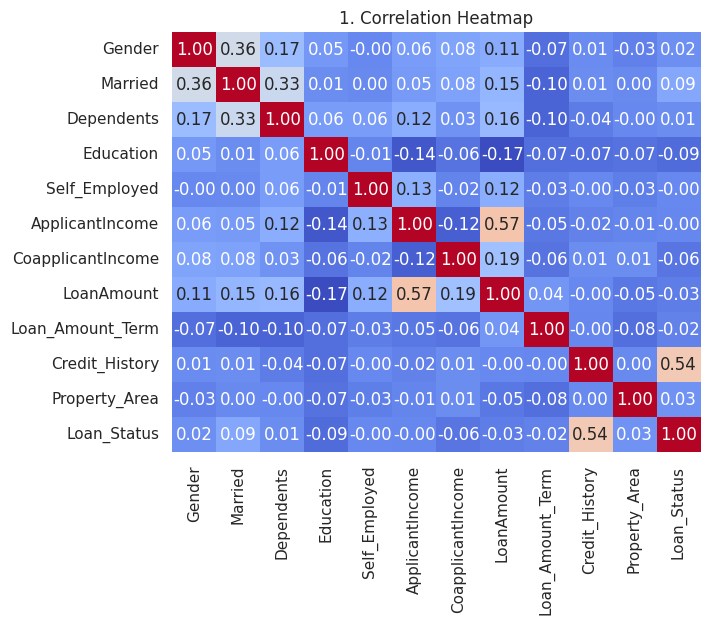

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
numeric_df_for_corr = df.drop(columns=['Loan_ID'], errors='ignore').select_dtypes(include=np.number)
sns.heatmap(numeric_df_for_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('1. Correlation Heatmap')
plt.show()

# Distribution Plot (Applicant Income)


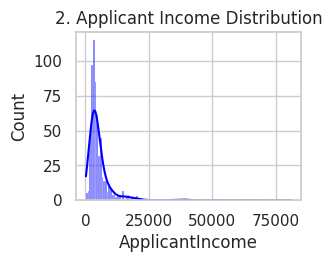

In [ ]:
plt.subplot(2, 2, 2)
sns.histplot(df[df.columns[df.columns.str.contains('Income|income')][0]], kde=True, color='blue') #Auto select first income column
plt.title('2. Applicant Income Distribution')
plt.show()

##Loan Status Analysis (Target Count)

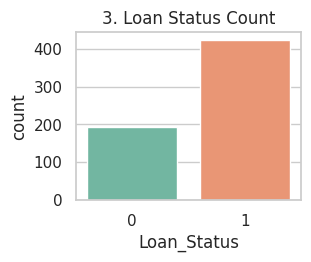

In [ ]:
plt.subplot(2, 2, 3)
sns.countplot(x=y, hue=y, palette='Set2', legend=False)
plt.title('3. Loan Status Count')
plt.show()

#Income vs Loan Approval Analysis

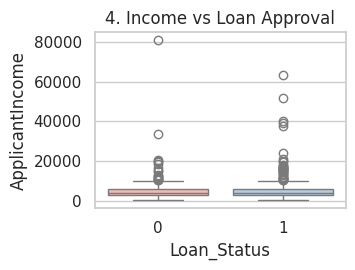

In [ ]:
plt.subplot(2, 2, 4)
income_col = df.columns[df.columns.str.contains('Income|income')][0]
sns.boxplot(x=y, y=df[income_col], hue=y, palette='Pastel1', legend=False)
plt.title('4. Income vs Loan Approval')

plt.tight_layout()
plt.show()

#Property Area vs Loan Status

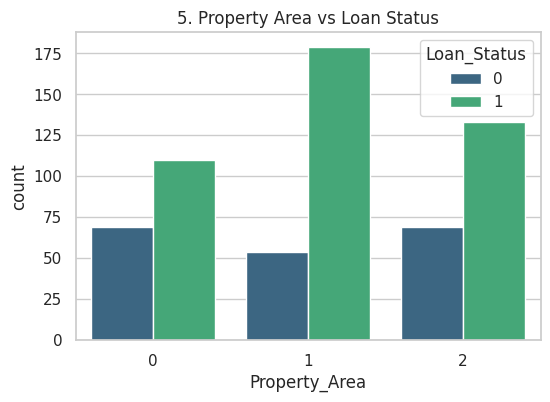

In [ ]:
plt.figure(figsize=(6, 4))
if 'Property_Area' in df.columns:
    sns.countplot(x='Property_Area', hue=y, data=df, palette='viridis')
    plt.title('5. Property Area vs Loan Status')
else:
    # Backup if column  naam little changed
    sns.countplot(x=X.columns[0], hue=y, data=df, palette='viridis')
    plt.title(f'5. {X.columns[0]} vs Loan Status')
plt.show()

#MODEL BUILDING & EVALUATION

In [ ]:
# Models Initialize
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
    "Random Forest Classifier": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    # Model Train
    model.fit(X_train_scaled, y_train)
    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Metrics Calculate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = [acc, prec, rec, f1]

    print(f" {name} Results:")
    print(f"Confusion Matrix:\n{cm}")
    print(classification_report(y_test, y_pred, zero_division=0))

 Logistic Regression Results:
Confusion Matrix:
[[18 25]
 [ 1 79]]
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

 Decision Tree Classifier Results:
Confusion Matrix:
[[23 20]
 [18 62]]
              precision    recall  f1-score   support

           0       0.56      0.53      0.55        43
           1       0.76      0.78      0.77        80

    accuracy                           0.69       123
   macro avg       0.66      0.65      0.66       123
weighted avg       0.69      0.69      0.69       123

 Random Forest Classifier Results:
Confusion Matrix:
[[18 25]
 [ 6 74]]
              precision    recall  f1-score   support

           0       0.75      0.42      0.54        43
           1       0.75   

#COMPARISON

In [ ]:
comparison_df = pd.DataFrame(results, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
print(comparison_df)

best_model = comparison_df['Accuracy'].idxmax()
print(f"\n best model **{best_model}** cuz of higher accuracy ")

                          Accuracy  Precision  Recall  F1-Score
Logistic Regression       0.788618   0.759615  0.9875  0.858696
Decision Tree Classifier  0.691057   0.756098  0.7750  0.765432
Random Forest Classifier  0.747967   0.747475  0.9250  0.826816

 best model **Logistic Regression** cuz of higher accuracy 


#Prediction

In [ ]:
# --- NEW APPLICANT LOAN PREDICTION ---

# 1. Enter new data of customer (numbers can be changed by you)
# Features's sequence: [Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area]
# Note: Categorical values  are encoded  (e.g., Male=1, Married=1, Graduate=0, Credit_History=1.0)

naya_customer_data = np.array([[
   1,   # Gender (e.g., Male = 1)
   1,   # Married (e.g., Yes = 1)
   0,   # Dependents (e.g., No kids = 0)
   0,   # Education (e.g., Graduate = 0)
   0,   # Self_Employed (e.g., No = 0)
   5000, # ApplicantIncome (Mahana Aamdani)
   0,   # CoapplicantIncome
   150, # LoanAmount (Jitna loan chahiye, e.g., 150k)
   360, # Loan_Amount_Term (Days/Months)
   1.0, # Credit_History (Good Credit = 1.0, Bad = 0.0) NOTE:- CREDIT_HISTORY IMPORTANT ACCORDING TO OUR DATA SO IF BAD=0.0 LOAN WIL BE REJECTED.
   2    # Property_Area (e.g., Urban = 2)
]])

# Get the feature names from X_train
feature_names = X_train.columns

# Convert naya_customer_data to a DataFrame with feature names
naya_customer_df = pd.DataFrame(naya_customer_data, columns=feature_names)

# 2. Data scale (CUZ model trained on scaled data)
naya_customer_scaled = scaler.transform(naya_customer_df)

# 3. Logistic Regression model predict
faisla = models["Logistic Regression"].predict(naya_customer_scaled)

# 4. Result print
if faisla[0] == 1:
    print(" RESULT: LOAN APPROVED!")
else:
    print(" RESULT: LOAN REJECTED!")

 RESULT: LOAN APPROVED!


#SECOND_METHOD_TO_TAKE_PREDICTION

#Interactive Input Form / "ML Web App Prototype" (Machine Learning Application small model)

In [ ]:
import pandas as pd
import numpy as np

#@title  Loan Predictor Form { run: "auto" }

# 1. Inputs directly from the Colab Sidebar Form
Gender = "Male" #@param ["Male", "Female"]
Married = "Yes" #@param ["Yes", "No"]
Dependents = "0" #@param ["0", "1", "2", "3+"]
Education = "Graduate" #@param ["Graduate", "Not Graduate"]
Self_Employed = "No" #@param ["Yes", "No"]
ApplicantIncome = 5000 #@param {type:"slider", min:1000, max:50000, step:500}
CoapplicantIncome = 0 #@param {type:"number"}
LoanAmount = 150 #@param {type:"number"}
Loan_Amount_Term = 360 #@param {type:"number"}
Credit_History = "Good (1.0)" #@param ["Good (1.0)", "Bad (0.0)"]
Property_Area = "Urban" #@param ["Urban", "Semiurban", "Rural"]

# --- ENCODING PROCESS (Auto Translate fields to numbers) ---
g_enc = 1 if Gender == "Male" else 0
m_enc = 1 if Married == "Yes" else 0
d_enc = 3 if Dependents == "3+" else int(Dependents)
e_enc = 0 if Education == "Graduate" else 1
s_enc = 1 if Self_Employed == "Yes" else 0
ch_enc = 1.0 if "Good" in Credit_History else 0.0

if Property_Area == "Urban":      p_enc = 2
elif Property_Area == "Semiurban": p_enc = 1
else:                              p_enc = 0

# --- PREDICTION ENGINE ---
# 1. Create Data Row
form_data_array = np.array([[g_enc, m_enc, d_enc, e_enc, s_enc, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, ch_enc, p_enc]])

# Get the feature names from X_train (assuming X_train is available in the kernel state)
feature_names = X_train.columns

# Convert form_data_array to a DataFrame with feature names
form_data_df = pd.DataFrame(form_data_array, columns=feature_names)

# 2. Scale features
form_scaled = scaler.transform(form_data_df)

# 3. Predict using Logistic Regression
prediction = models["Logistic Regression"].predict(form_scaled)

# 4. Show Result Beautifully

if prediction[0] == 1 or prediction[0] == 'Y':
    print("LOAN APPROVED!")
else:
    print("LOAN REJECTED!")

LOAN APPROVED!
